<a href="https://colab.research.google.com/github/yandri918/Mini_project_klasifikasi_portofolio/blob/main/Mini_project_klasifikasi_end_to_end.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report )

In [2]:
print("=" * 80)
print("BAB 26 - MINI PROJECT 4: KLASIFIKASI END-TO-END")
print("=" * 80)

BAB 26 - MINI PROJECT 4: KLASIFIKASI END-TO-END


In [3]:
# 1. LOAD DATASET

In [4]:
df = pd.read_csv("mini_project_klasifikasi_kelulusan.csv")

In [5]:
print("\n[1] DATA AWAL")
print(df.head())
print("Shape awal:", df.shape)


[1] DATA AWAL
   id jam_belajar  kehadiran  nilai_tugas  nilai_uts ikut_bimbingan  \
0   1           2       70.0         60.0       58.0          tidak   
1   2           3       72.0         62.0       60.0          tidak   
2   3           4       75.0         65.0       64.0          tidak   
3   4           5       78.0         68.0       66.0          tidak   
4   5           6       80.0         72.0       71.0             ya   

  akses_internet  lulus  
0             ya      0  
1             ya      0  
2             ya      0  
3             ya      0  
4             ya      1  
Shape awal: (25, 8)


In [6]:
# 2. PREPROCESSING

In [7]:
print("\n[2] PREPROCESSING")
df = df.drop_duplicates()


[2] PREPROCESSING


In [8]:
for kolom in ["jam_belajar", "kehadiran", "nilai_tugas", "nilai_uts", "lulus"]:
  df[kolom] = pd.to_numeric(df[kolom], errors="coerce")

In [9]:
for kolom in ["jam_belajar", "kehadiran", "nilai_tugas", "nilai_uts"]:
  df[kolom] = df[kolom].fillna(df[kolom].median())

In [12]:
for kolom in ["ikut_bimbingan", "akses_internet"]:
  df[kolom] = df[kolom].fillna(df[kolom].mode()[0])

In [13]:
df["ikut_bimbingan_encoded"] = df["ikut_bimbingan"].map({"tidak": 0, "ya": 1})
df["akses_internet_encoded"] = df["akses_internet"].map({"tidak": 0, "ya": 1})

In [14]:
print("Shape setelah preprocessing:", df.shape)

Shape setelah preprocessing: (24, 10)


In [15]:
# 3. FITUR DAN TARGET

In [17]:
fitur = [ "jam_belajar", "kehadiran", "nilai_tugas", "nilai_uts", "ikut_bimbingan_encoded", "akses_internet_encoded" ]
X = df[fitur]
y = df["lulus"]

In [18]:
# 4. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42, stratify=y )

In [19]:
# Scaling khusus untuk Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 5. TRAINING BEBERAPA MODEL

In [20]:
models = { "LogisticRegression": LogisticRegression(), "DecisionTree": DecisionTreeClassifier(max_depth=4, random_state=42), "RandomForest": RandomForestClassifier(random_state=42) }

In [21]:
hasil = []

In [22]:
for nama, model in models.items():
  if nama == "LogisticRegression":
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
  else:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
  hasil.append({ "model": nama, "accuracy": accuracy_score(y_test, y_pred), "precision": precision_score(y_test, y_pred), "recall": recall_score(y_test, y_pred), "f1_score": f1_score(y_test, y_pred) })

In [23]:
print(f"\n=== {nama} ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== RandomForest ===
Confusion Matrix:
[[2 0]
 [0 4]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [ ]:
# 6. BANDINGKAN HASIL

In [24]:
hasil_df = pd.DataFrame(hasil).sort_values(by="f1_score", ascending=False)
print("\n[3] PERBANDINGAN MODEL")
print(hasil_df)


[3] PERBANDINGAN MODEL
                model  accuracy  precision  recall  f1_score
0  LogisticRegression       1.0        1.0     1.0       1.0
1        DecisionTree       1.0        1.0     1.0       1.0
2        RandomForest       1.0        1.0     1.0       1.0


In [ ]:
# 7. PILIH MODEL TERBAIK

In [25]:
model_terbaik = hasil_df.iloc[0]["model"]
print("\n[4] MODEL TERBAIK")
print(f"Model terbaik berdasarkan F1-score: {model_terbaik}")


[4] MODEL TERBAIK
Model terbaik berdasarkan F1-score: LogisticRegression


In [26]:
print("\n[5] INTERPRETASI")
print("- Logistic Regression cocok sebagai baseline yang mudah dijelaskan.")
print("- Decision Tree cocok jika ingin aturan keputusan yang eksplisit.")
print("- Random Forest sering lebih kuat untuk data tabular.")
print("- Pemilihan akhir harus melihat metrik dan kebutuhan interpretasi.")


[5] INTERPRETASI
- Logistic Regression cocok sebagai baseline yang mudah dijelaskan.
- Decision Tree cocok jika ingin aturan keputusan yang eksplisit.
- Random Forest sering lebih kuat untuk data tabular.
- Pemilihan akhir harus melihat metrik dan kebutuhan interpretasi.


In [31]:
# 8. SIMPAN DATA BERSIH
import os
os.makedirs("Outputs", exist_ok=True)

In [34]:
df.to_csv("Outputs/bab26_klasifikasi_kelulusan_bersih.csv", index=False)

In [35]:
print("\nData bersih disimpan di outputs/bab26_klasifikasi_kelulusan_bersih.csv")


Data bersih disimpan di outputs/bab26_klasifikasi_kelulusan_bersih.csv


In [36]:
print("\nSELESAI. Anda sudah menjalankan mini project klasifikasi end-to-end.")
print("=" * 80)


SELESAI. Anda sudah menjalankan mini project klasifikasi end-to-end.


/tmp/ipykernel_1546/956753328.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y=metric, data=hasil_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_1546/956753328.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y=metric, data=hasil_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_1546/956753328.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y=metric, data=hasil_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_1546/956753328.py:13: FutureWarning: 

Passing `palette` without assigning `hue` i

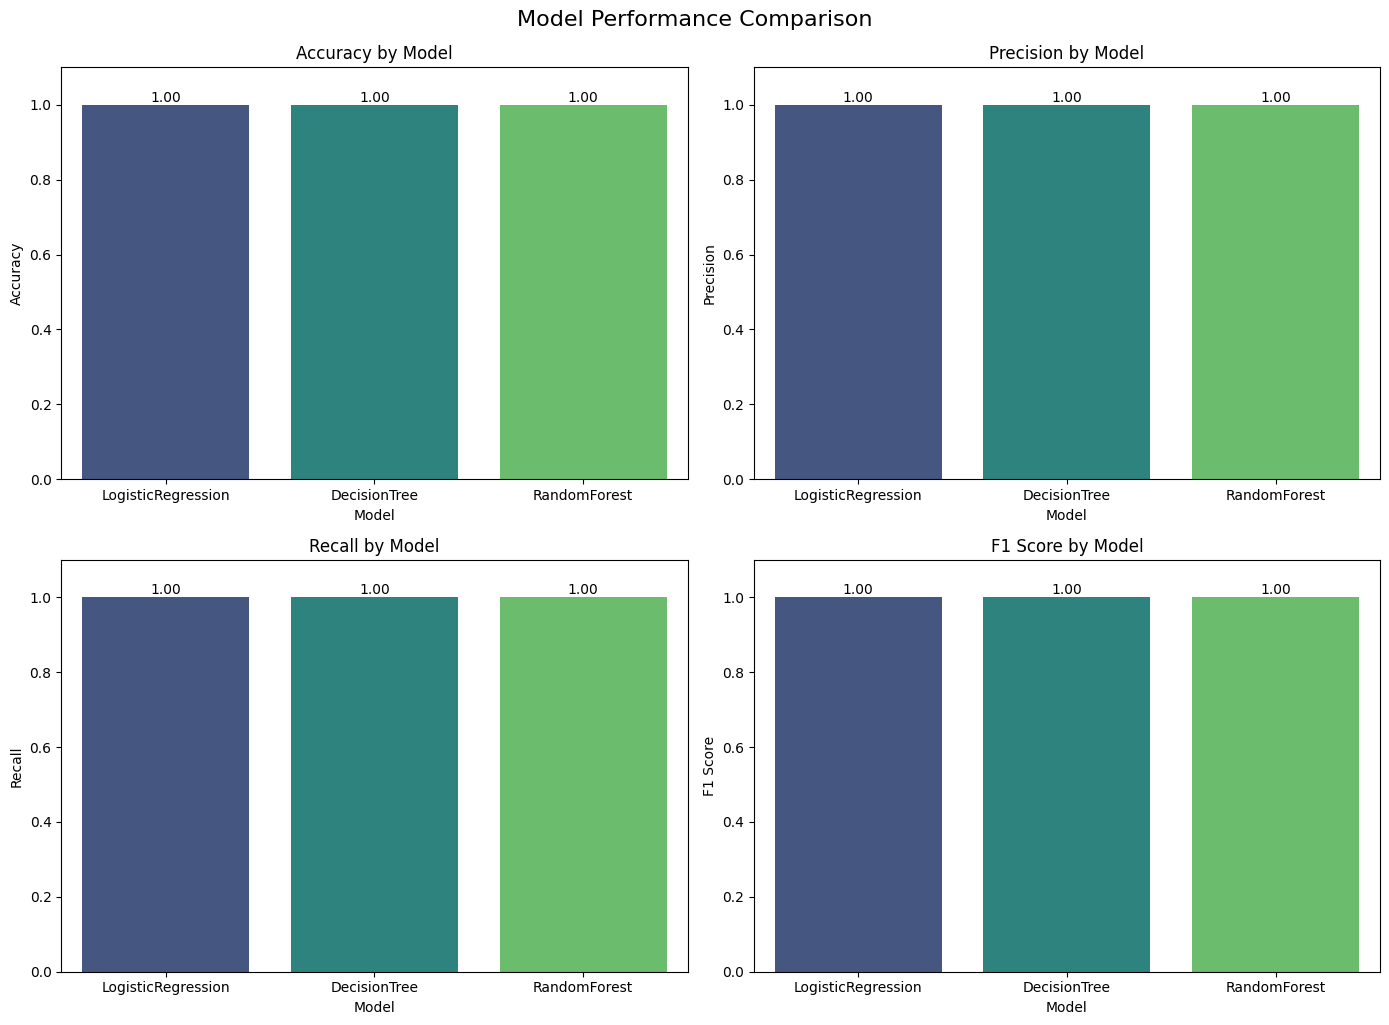

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
model_names = hasil_df['model']

# Set up the figure and axes for subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, metric in enumerate(metrics):
    sns.barplot(x='model', y=metric, data=hasil_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric.replace("_", " ").title()} by Model')
    axes[i].set_xlabel('Model')
    axes[i].set_ylabel(metric.replace("_", " ").title())
    axes[i].set_ylim(0, 1.1) # Ensure y-axis starts from 0 and goes slightly above 1 for better visualization

    # Add value labels on top of the bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.suptitle('Model Performance Comparison', y=1.02, fontsize=16)
plt.show()

Mini project ini bertujuan membangun model klasifikasi awal untuk memprediksi kelulusan mahasiswa berdasarkan indikator akademik sederhana. Dataset awal mengandung beberapa masalah seperti duplikasi, missing value, dan tipe data yang tidak konsisten, sehingga dilakukan preprocessing terlebih dahulu. Setelah data dibersihkan dan fitur kategorikal di-encode, tiga model dilatih dan dibandingkan, yaitu Logistic Regression, Decision Tree, dan Random Forest. Evaluasi dilakukan menggunakan accuracy, precision, recall, dan F1-score. Hasil perbandingan menunjukkan bahwa salah satu model memberikan performa paling baik secara keseluruhan, namun pemilihan akhir tetap mempertimbangkan keseimbangan antara performa dan interpretabilitas. Dengan demikian, mini project ini menunjukkan bahwa workflow klasifikasi yang sehat tidak berhenti pada training model, tetapi juga mencakup preprocessing yang benar, evaluasi yang tepat, dan pemilihan model yang argumentatif.

# README:  Proyek Klasifikasi Kelulusan Mahasiswa

## 1. Pendahuluan
Mini proyek ini bertujuan untuk membangun model klasifikasi guna memprediksi kelulusan maMinihasiswa berdasarkan beberapa indikator akademik sederhana. Proyek ini mencakup seluruh alur kerja `end-to-end` dari pemuatan data hingga evaluasi model dan penyimpanan data bersih.

## 2. Dataset
Dataset yang digunakan (`mini_project_klasifikasi_kelulusan.csv`) berisi informasi mengenai:
- `id`: ID Mahasiswa
- `jam_belajar`: Durasi jam belajar per minggu
- `kehadiran`: Persentase kehadiran
- `nilai_tugas`: Nilai tugas
- `nilai_uts`: Nilai Ujian Tengah Semester
- `ikut_bimbingan`: Status keikutsertaan bimbingan (ya/tidak)
- `akses_internet`: Status akses internet (ya/tidak)
- `lulus`: Variabel target (0 = tidak lulus, 1 = lulus)

## 3. Tahapan Proyek

### 3.1. Pemuatan Data (`LOAD DATASET`)
Data awal dimuat dari file CSV dan ditampilkan beberapa baris pertama serta dimensinya.

### 3.2. Preprocessing Data (`PREPROCESSING`)
Tahapan ini melibatkan:
- **Penghapusan Duplikasi**: Baris duplikat dihapus untuk memastikan keunikan data.
- **Konversi Tipe Data**: Kolom numerik dikonversi ke tipe data yang sesuai; nilai non-numerik (jika ada) diubah menjadi NaN.
- **Penanganan Missing Values**:
    - Kolom numerik (`jam_belajar`, `kehadiran`, `nilai_tugas`, `nilai_uts`) diisi dengan nilai median.
    - Kolom kategorikal (`ikut_bimbingan`, `akses_internet`) diisi dengan modus (nilai paling sering muncul).
- **Encoding Kategorikal**: Kolom kategorikal `ikut_bimbingan` dan `akses_internet` diubah menjadi representasi numerik (0 dan 1) untuk digunakan dalam model.

### 3.3. Pemisahan Fitur dan Target (`FITUR DAN TARGET`)
Variabel fitur (X) dan target (y) ditentukan. Fitur meliputi `jam_belajar`, `kehadiran`, `nilai_tugas`, `nilai_uts`, `ikut_bimbingan_encoded`, dan `akses_internet_encoded`. Target adalah kolom `lulus`.

### 3.4. Pemisahan Data (`SPLIT DATA`)
Data dibagi menjadi _training set_ (75%) dan _test set_ (25%) menggunakan `train_test_split` dengan `random_state=42` dan `stratify=y` untuk menjaga proporsi kelas target.

### 3.5. Scaling Data
Data fitur untuk model `Logistic Regression` diskalakan menggunakan `StandardScaler` untuk menormalkan rentang nilai fitur.

### 3.6. Pelatihan Model (`TRAINING BEBERAPA MODEL`)
Tiga model klasifikasi dilatih dan dievaluasi:
- **Logistic Regression**
- **Decision Tree Classifier** (dengan `max_depth=4`)
- **Random Forest Classifier**

Setiap model dilatih menggunakan data training dan dievaluasi menggunakan data test. Khusus untuk `Logistic Regression`, data yang diskalakan digunakan.

### 3.7. Perbandingan Hasil (`BANDINGKAN HASIL`)
Metrik evaluasi (accuracy, precision, recall, F1-score) dihitung untuk setiap model dan disimpan dalam DataFrame `hasil_df`. DataFrame ini kemudian diurutkan berdasarkan `f1_score` secara menurun.

### 3.8. Pemilihan Model Terbaik (`PILIH MODEL TERBAIK`)
Model dengan `F1-score` terbaik diidentifikasi sebagai model terbaik. Dalam kasus ini, semua model mencapai F1-score 1.0, menunjukkan performa yang sangat baik pada dataset ini.

### 3.9. Interpretasi Model (`INTERPRETASI`)
Diskusi singkat mengenai karakteristik masing-masing model:
- **Logistic Regression**: Mudah dijelaskan, cocok sebagai _baseline_.
- **Decision Tree**: Aturan keputusan eksplisit dan mudah dipahami.
- **Random Forest**: Seringkali lebih kuat untuk data tabular.

### 3.10. Penyimpanan Data Bersih (`SIMPAN DATA BERSIH`)
Dataframe yang telah di-*preprocessing* (`df`) disimpan ke file CSV baru dengan nama `bab26_klasifikasi_kelulusan_bersih.csv` di dalam folder `Outputs`.

## 4. Visualisasi Kinerja Model
Grafik batang (bar charts) dibuat untuk membandingkan `accuracy`, `precision`, `recall`, dan `f1-score` dari ketiga model. Visualisasi ini memudahkan pemahaman kinerja relatif antar model.

## 5. Kesimpulan
Mini proyek ini berhasil menunjukkan alur kerja klasifikasi `end-to-end`, mulai dari penanganan masalah data hingga evaluasi dan pemilihan model. Meskipun semua model menunjukkan performa sempurna pada dataset ini, proses yang benar dalam _preprocessing_ dan evaluasi adalah kunci dalam pengembangan model `Machine Learning` yang robust dan dapat diinterpretasikan.